# ViCLIP loading

In [53]:
import ViCLIP

In [54]:
# Mac settings
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Data Processing

## SSv2

In [89]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("ipythonx/k4testset")

# print("Path to dataset files:", path)

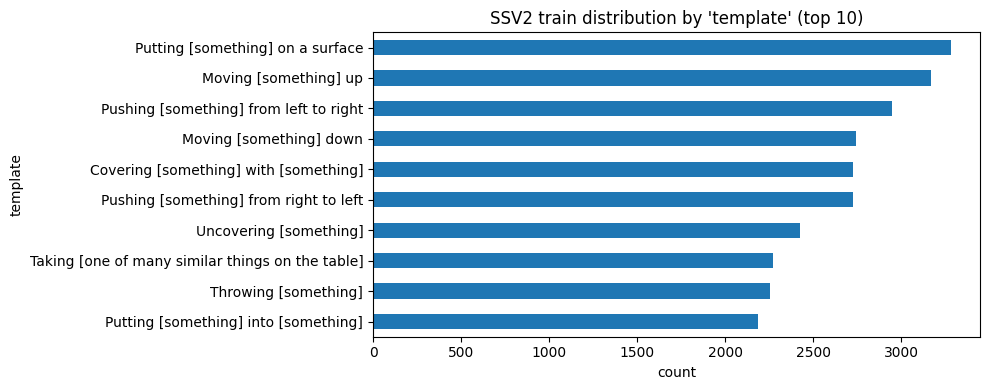

train samples: 168,913
unique template: 174


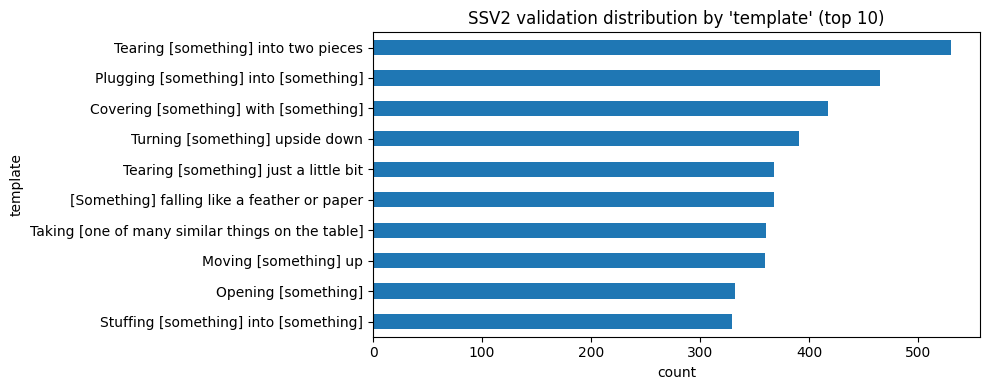

validation samples: 24,777
unique template: 174


In [ ]:
# Basic SSV2 analysis + visualization
from pathlib import Path
import json
import zipfile

import pandas as pd
import matplotlib.pyplot as plt

SSV2_ROOT = Path("datasets/ssv2")
LABELS_DIR = SSV2_ROOT / "20bn-something-something-download-package-labels" / "labels"  # contains train.json, validation.json, test.json, labels.json
VIDEO_DIR = SSV2_ROOT / "extracted" / "20bn-something-something-v2"  # contains <id>.webm


def load_split(split: str) -> pd.DataFrame:
    assert split in {"train", "validation", "test"}
    with open(LABELS_DIR / f"{split}.json") as f:
        data = json.load(f)
    return pd.DataFrame(data)


def load_label_map() -> dict:
    with open(LABELS_DIR / "labels.json") as f:
        return json.load(f)


def plot_label_distribution(split="train", by="template", top_k=25):
    """
    by:
      - 'template' (recommended class label for SSV2)
      - 'label'    (free text with placeholders filled in, very long-tail)
    """
    df = load_split(split)
    if by not in df.columns:
        raise ValueError(f"'{by}' not in columns: {df.columns.tolist()}")

    counts = df[by].value_counts().head(top_k)
    ax = counts.sort_values().plot(kind="barh", figsize=(10, max(4, 0.35 * len(counts))))
    ax.set_title(f"SSV2 {split} distribution by '{by}' (top {len(counts)})")
    ax.set_xlabel("count")
    ax.set_ylabel(by)
    plt.tight_layout()
    plt.show()

    print(f"{split} samples: {len(df):,}")
    print(f"unique {by}: {df[by].nunique():,}")


plot_label_distribution("train", by="template", top_k=10)
plot_label_distribution("validation", by="template", top_k=10)

In [96]:
import random
from IPython.display import Video, display


def show_example_video(split="train", idx=None, video_id=None, autoplay=False):
    """
    Pick sample by idx or video_id and display video + label metadata.
    """
    df = load_split(split)

    if video_id is not None:
        row = df[df["id"].astype(str) == str(video_id)]
        if row.empty:
            raise ValueError(f"video_id={video_id} not found in {split}")
        row = row.iloc[0]
    else:
        if idx is None:
            idx = random.randrange(len(df))
        row = df.iloc[idx]

    vid = str(row["id"])
    video_path = VIDEO_DIR / f"{vid}.webm"

    print(f"split: {split}")
    print(f"id: {vid}")
    if "template" in row:
        print(f"template: {row['template']}")
    if "label" in row:
        print(f"label: {row['label']}")
    if "placeholders" in row:
        print(f"placeholders: {row['placeholders']}")
    print(f"video_path: {video_path}")

    if not video_path.exists():
        print("Video file not found (check extraction path).")
        return

    display(Video(str(video_path), embed=True, html_attributes="controls"))

In [97]:
import os
import random

from torchvision.datasets.folder import has_file_allowed_extension
from torchvision import transforms, datasets
from typing import Callable, Optional, Union, cast

def make_dataset(
    directory: Union[str, Path],
    class_to_idx: Optional[dict[str, int]] = None,
    extensions: Optional[Union[str, tuple[str, ...]]] = None,
    is_valid_file: Optional[Callable[[str], bool]] = None,
    allow_empty: bool = False,
) -> list[tuple[str, int]]:
    """
    Note: Function adapted from torchvision for a simpler dataset structure.

    Generates a list of samples of a form (path_to_sample, class).

    See :class:`DatasetFolder` for details.

    Note: The class_to_idx parameter is here optional and will use the logic of the ``find_classes`` function
    by default.
    """
    directory = os.path.expanduser(directory)

    if not class_to_idx:
        raise ValueError("'class_to_index' must have at least one entry to collect any samples.")

    both_none = extensions is None and is_valid_file is None
    both_something = extensions is not None and is_valid_file is not None
    if both_none or both_something:
        raise ValueError("Both extensions and is_valid_file cannot be None or not None at the same time")

    if extensions is not None:

        def is_valid_file(x: str) -> bool:
            return has_file_allowed_extension(x, extensions)  # type: ignore[arg-type]

    is_valid_file = cast(Callable[[str], bool], is_valid_file)

    instances = []
    available_classes = set()
    for target_class in sorted(class_to_idx.keys()):
        class_index = {"label": class_to_idx[target_class]}
        target_dir = directory #os.path.join(directory, target_class)
        if not os.path.isdir(target_dir):
            continue
        for root, _, fnames in sorted(os.walk(target_dir, followlinks=True)):
            for fname in sorted(fnames):
                path = os.path.join(root, fname)
                if is_valid_file(path):
                    item = path, class_index
                    instances.append(item)

                    if target_class not in available_classes:
                        available_classes.add(target_class)

    empty_classes = set(class_to_idx.keys()) - available_classes
    if empty_classes and not allow_empty:
        msg = f"Found no valid file for the classes {', '.join(sorted(empty_classes))}. "
        if extensions is not None:
            msg += f"Supported extensions are: {extensions if isinstance(extensions, str) else ', '.join(extensions)}"
        raise FileNotFoundError(msg)

    return instances

In [98]:
from pytorchvideo.transforms import UniformTemporalSubsample, ApplyTransformToKey, ShortSideScale, \
    Normalize
from torchvision.transforms import Compose, Lambda, ToTensor
from torchvision.transforms import Resize, CenterCrop

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


preprocessing = Compose([
    ApplyTransformToKey(
        key="video",
        transform=Compose([
            UniformTemporalSubsample(8),
            Lambda(lambda x: x / 255.0),
            Resize((224, 224)),
            CenterCrop(224),
            Normalize(IMAGENET_MEAN, IMAGENET_STD),  # TODO: evaluate normalization
            Lambda(lambda x: x.permute(1, 0, 2, 3)),  # C T H W -> T C H W
        ]),
    ),
])


In [99]:
from pytorchvideo import data

with open(LABELS_DIR / "labels.json") as f:
    class_to_idx = json.load(f)
labeled_video_paths=make_dataset(
    SSV2_ROOT / "extracted" / "20bn-something-something-v2",
    class_to_idx,
    ".webm"
)
clip_sampler = data.UniformClipSampler(clip_duration=3.0)  # TODO review sampling strategy

In [100]:
dst = data.LabeledVideoDataset(
    labeled_video_paths=labeled_video_paths,
    clip_sampler=clip_sampler,
    transform=preprocessing,
)

# TODO to mps
dst_element = next(iter(dst))

In [102]:
dst_element = next(iter(dst))
dst_element['video_name']

'196358.webm'

In [103]:
dst_element['label']
class_txt = [k for k, v in class_to_idx.items() if v == dst_element['label']][0]
print(f"video label: {class_txt}")

video label: Putting something on a surface


# Classification

In [104]:
from typing import List

import torch
from ViCLIP.simple_tokenizer import SimpleTokenizer
from TextToConcept import ZeroShotClassifier
from torchvision import datasets, transforms

class ClipZeroShotForImages(torch.nn.Module):
    def __init__(self, mtype):
        """Loads the CLIP model for zero-shot classification.

        Args:
            mtype (str): model type
        """
        super(ClipZeroShotForImages, self).__init__()
        self.clip_model, self.clip_preprocess = clip.load(mtype)
        self.to_pil = transforms.ToPILImage()
        self.mtype = mtype
        self.has_normalizer = False
        
    def forward_features(self, img):
        image_features = self.clip_model.encode_image(img)
        return image_features
    
    def encode_text(self, tokens):
        return self.clip_model.encode_text(tokens)

    def tokenize(self, texts: List[str]):
        return self.clip_model.tokenize(texts)


class ClipZeroShotForVideos(torch.nn.Module):
    def __init__(self, mtype):
        """Loads the CLIP model for zero-shot classification.

        Args:
            mtype (str): model type
        """
        super(ClipZeroShotForVideos, self).__init__()
        self.tokenizer = SimpleTokenizer()
        self.clip_model = ViCLIP.ViCLIP(self.tokenizer)

        # self.clip_model, self.clip_preprocess = clip.load(mtype)
        self.to_pil = transforms.ToPILImage()
        self.mtype = mtype
        self.has_normalizer = False

    def forward_features(self, vid):
        video_feats = self.clip_model.get_vid_features(vid)
        return video_feats

    def encode_text(self, tokens):
        return self.clip_model.encode_text(tokens)

    def tokenize(self, texts: List[str]):
        return self.clip_model.tokenize(texts)

In [105]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
clip_4vid = ClipZeroShotForVideos("ViT-B/32").to(device)

In [60]:
from torchvision.io.video import read_video

# video_path = VIDEO_DIR / "220384.webm"
video_path = VIDEO_DIR / "55.webm"
video, _, metadata = read_video(video_path)
video.shape  # [T, H, W, C]

/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/torchvision/io/video.py:199: UserWarning: The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.
  warnings.warn("The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.")


torch.Size([34, 240, 320, 3])

In [94]:
dst_element

{'video': tensor([[[[674.6271, 612.1268, 600.9592,  ..., 714.8705, 704.2570, 363.2329],
           [713.8457, 644.6832, 589.9980,  ..., 678.0807, 673.5864, 365.9951],
           [731.3358, 682.0522, 587.5281,  ..., 676.3437, 700.3160, 386.6541],
           ...,
           [724.1833, 721.3442, 712.6517,  ..., 675.6245, 567.9012, 266.2368],
           [735.4620, 741.5977, 735.6039,  ..., 591.8771, 505.4831, 255.6780],
           [726.0805, 726.7616, 712.0049,  ..., 514.9745, 503.3483, 266.0921]],
 
          [[646.9785, 580.2980, 563.8786,  ..., 736.3256, 723.4354, 371.4702],
           [685.4582, 611.1398, 552.1382,  ..., 698.9979, 690.1072, 373.5381],
           [706.1288, 652.2047, 550.4148,  ..., 692.5817, 713.1472, 390.5761],
           ...,
           [704.8506, 705.8314, 701.4296,  ..., 694.2606, 583.8106, 272.3090],
           [710.9917, 719.1509, 717.5807,  ..., 601.7053, 508.4716, 253.7770],
           [700.3252, 702.5886, 692.1592,  ..., 521.7690, 502.9751, 264.2662]],
 
     

In [84]:
dst_element = next(iter(dst))

In [106]:
video_feats = clip_4vid.forward_features(dst_element['video'].unsqueeze(0).to(device))
video_feats.shape

/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


torch.Size([1, 768])

In [110]:
dst_element.keys()

dict_keys(['video', 'video_name', 'video_index', 'clip_index', 'aug_index', 'label'])

In [109]:
texts = [
    # "a video of a person opening something",
    # "a video of a hand moving a cup",
    f"a video of someone {class_txt}",
    "a video of a toothbrush",
    "a video of an interview",
    "a video of someone pushing something on the table",
    "a video of someone pushing a can",
    "a video of a gorilla",
    "a video of someone turning a knob",
]
text_tokens = clip_4vid.tokenize(texts)
text_feats = clip_4vid.encode_text(text_tokens)

text_feats /= text_feats.norm(dim=-1, keepdim=True)
video_feats /= video_feats.norm(dim=-1, keepdim=True)
video_feats @ text_feats.T

tensor([[0.1106, 0.1805, 0.0855, 0.0859, 0.0869, 0.0251, 0.0615]],
       device='mps:0')